**Building Simple Graphs**

*Terminologies*

Graph: Blueprint for application workflow. Collection of interconnected nodes and edges.

Nodes: Perform a specific action or represents an AI agent. Can be:
    > An LLM Call
    > A tool invocation(e.g a search API, a calculator)
    > A custom Python function
    > Another LangChain runnable

Edges: Pathways that connects your nodes and determines which node executes next. Types:
    > Conditional Edges: Decision points based on the output of a node
    > Direct Edges: Straightforward connections; the workflow simply moves from one node directly to the next.

State: Real-world AI systems need to maintain information throughout a conversation or task. The graph state is shared memory that is passed between nodes. Each node can read from this state and update it.

Entry Point(START): special node marks where your graph's execution begins. Starting line of your agent's journey.

Finish Point(END): Once a path reaches an END node, that part of the execution is complete.


In [2]:
#!/usr/bin/python3
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

#load environment
load_dotenv()

# llm setup
llm=ChatGroq(
    temperature=0.3,
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.3-70b-versatile"
)

# trigger llm
response = llm.invoke("Hello")
print(f"AI: {response.content}")

AI: Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?


**First Simple Graphs**

- Foundational understanding by building a very basic graph.

- Concept of headless graph, where nodes directly take input and return output, without needing a shared TypeDict state. Perfect for simple sequential tasks.

*LLM Call & Token Count*

- We want to call an LLM and then couting the tokens in its response. 

- Define two simple functions




In [9]:
def llm(input):
    model=ChatGroq(
        temperature=0.3,
        groq_api_key=os.getenv("GROQ_API_KEY"),
        model_name="llama-3.3-70b-versatile"
    )
    output=model.invoke(input)
    return output.content   #Return just the text content

def token_counter(input):
    tokens=str(input).split()   # Split the text into words
    count_no = len(tokens)
    return f"Number of tokens: {count_no}"

In [10]:
# Now use langGraph the Agent orchestration framework
from langgraph.graph import MessageGraph          #----> is depreciated
workflow=MessageGraph() 
workflow.add_node('LLM_Model', llm) #Add llm function as node
workflow.add_node('Get_Token_Counter', token_counter)  #Add token_counter as node

# Add an edge to connect the two nodes. LLM output goes to token counter
workflow.add_edge('LLM_Model', 'Get_Token_Counter')

# Start here
workflow.set_entry_point('LLM_Model')

# End here
workflow.set_finish_point('Get_Token_Counter')

# compile the graph into a runnable
app=workflow.compile()

# Invoke the app
# App sends the input to the LLM
# LLM gets response
# counts token
# for output in app.stream("What is an AI agent?")



C:\Users\PC\AppData\Local\Temp\ipykernel_10532\2122574627.py:3: LangGraphDeprecatedSinceV10: MessageGraph is deprecated in LangGraph v1.0.0, to be removed in v2.0.0. Please use StateGraph with a `messages` key instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  workflow=MessageGraph()


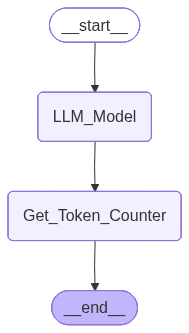

In [11]:


#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))



In [12]:
app.invoke('what is openclaw')

[HumanMessage(content='what is openclaw', additional_kwargs={}, response_metadata={}, id='4a9ca132-b9b3-48aa-b0ec-bf05fa01cc0c'),
 HumanMessage(content='OpenCLAW (Open-source CLAW) is an open-source implementation of the CLAW (Control, Learning, Adaptation, and Workflow) framework. CLAW is a software framework for developing and deploying machine learning (ML) and artificial intelligence (AI) applications, particularly those that require real-time processing and adaptation.\n\nThe CLAW framework was originally developed by researchers at the University of California, Berkeley, and was designed to provide a flexible and modular architecture for building and deploying ML/AI systems. The framework focuses on providing a set of tools and APIs for developing and integrating ML/AI components, such as data processing, feature extraction, model training, and inference.\n\nOpenCLAW is an open-source implementation of the CLAW framework, which aims to provide a community-driven and extensible pl

**Takeaways from the Example**

1. Graph Vs StateGraph:

- Graph() is simpler(MessageGraph). Used when the output of one node direcly becomes the input of the next.
All nodes read from and write to the state not TypedDict

- StateGraph() more complex allowing multiple nodes to read/write different parts of a shared, evolving state, often involving conditional logic and parallel execution.


2.  Direct Input/Output Flow: Look at the edge "workflow.add_edge('LLM_Model', 'Get_Token_Counter')" means that whatever llm functions returns will be passed as the single positional argument to token_counter function.


3. set_finish_point(): tells LangGraph which node's output should be returned as the final result of app.invoke()

